In [1]:
import scanpy as sc
sc._settings.ScanpyConfig.n_jobs=72
sc.logging.print_header()
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png',frameon=False)
sc._settings.ScanpyConfig.n_jobs=48
import mudata as md
import muon as mu

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import median_abs_deviation
from plotnine import ggplot, aes, theme_bw, geom_bin2d, scale_fill_cmap,facet_wrap

import datetime
from decimal import Decimal

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [2]:
obj_path = '/home/liyanguo/MyImmuCell/02_Read_QC/'
sc.settings.figdir = obj_path

# 1. QC of single-cell transcriptomes

In [3]:
adata = sc.read_h5ad(f"{obj_path}scRNA_Ref_Atlas.h5ad")

In [4]:
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

In [5]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["hb"], inplace=True, percent_top=[20], log1p=True
)

In [6]:
adata.obs['nFeature_RNA'].describe()

count    924890.000000
mean       1313.869126
std         693.397967
min          95.000000
25%         813.000000
50%        1130.000000
75%        1590.000000
max        8172.000000
Name: nFeature_RNA, dtype: float64

In [7]:
def is_outlier(anndata, metric: str, nmads: int):
    M = np.log2(anndata.obs[metric]+1)
    outlier_low1 = np.median(M) - nmads * median_abs_deviation(M)
    outlier_high1 = np.median(M) + nmads * median_abs_deviation(M)
    
    outlier_low = round(2 ** outlier_low1,0)
    outlier_high = round(2 ** outlier_high1,0)
    return outlier_low,outlier_high

In [8]:
nCount_RNA_low, nCount_RNA_high = is_outlier(adata, "total_counts", 4)
nFeature_RNA_low, nFeature_RNA_high = is_outlier(adata, "n_genes_by_counts", 4)

In [9]:
nFeature_RNA_low, nFeature_RNA_high, nCount_RNA_low, nCount_RNA_high

(297.0, 4308.0, 420.0, 11448.0)

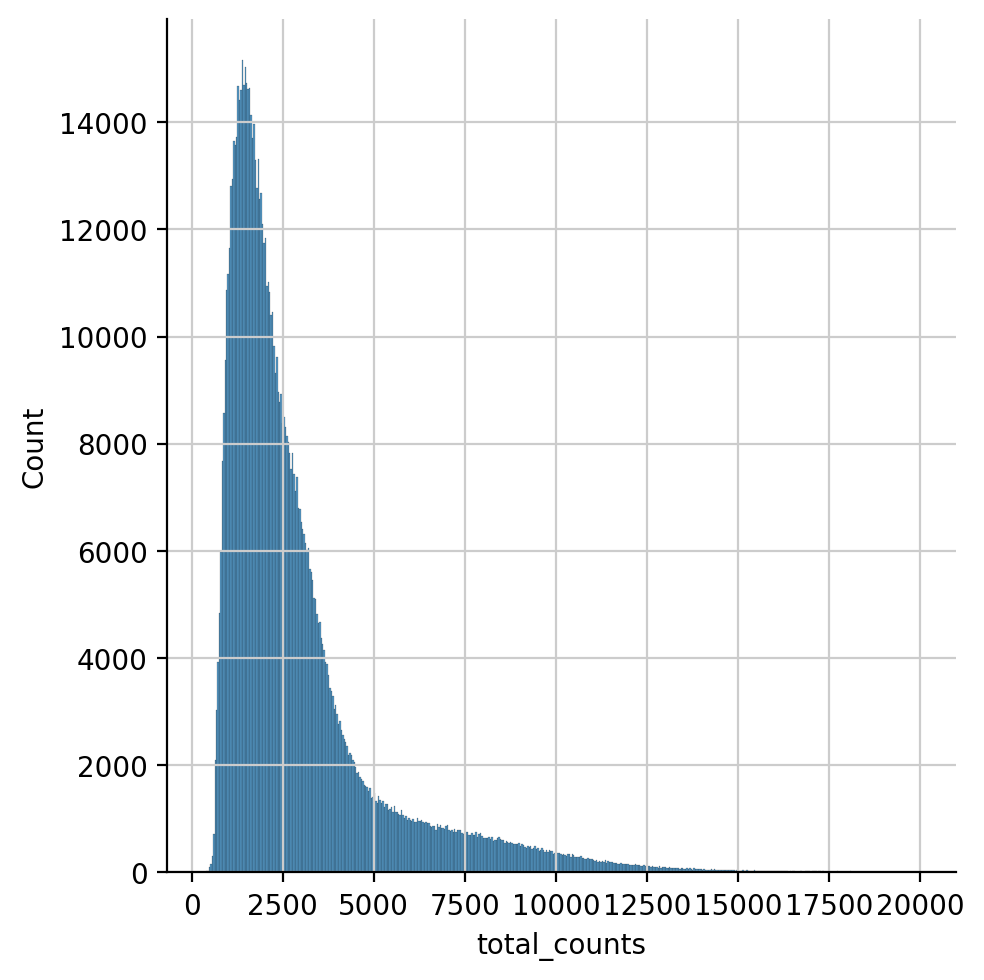

In [10]:
sns.displot(
    adata.obs.query("total_counts > 0 and total_counts < 20000").total_counts
)

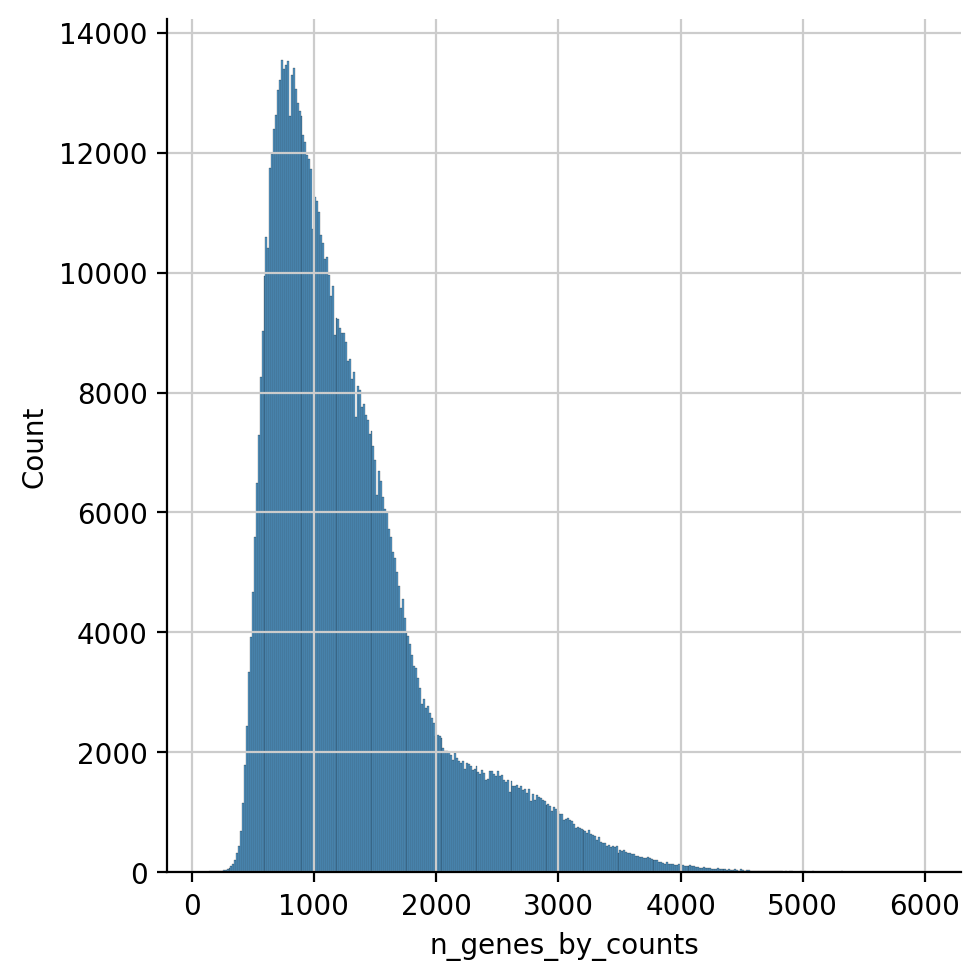

In [11]:
sns.displot(
    adata.obs.query("n_genes_by_counts > 0 and n_genes_by_counts < 6000").n_genes_by_counts
)

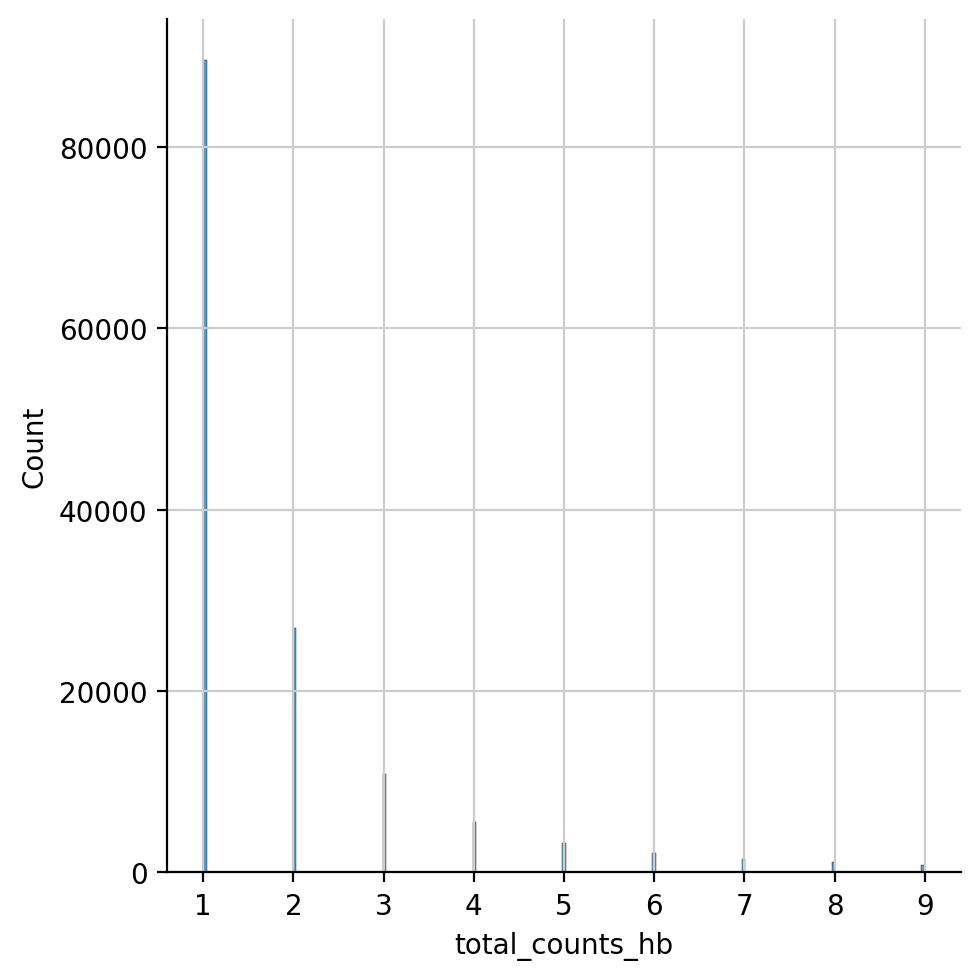

In [12]:
sns.displot(
    adata.obs.query("total_counts_hb > 0 and total_counts_hb < 10").total_counts_hb
)

In [13]:
print(
    (adata.obs["percent_mito"] < 10).value_counts(),
    (adata.obs["nFeature_RNA"] > nFeature_RNA_low).value_counts(),
    (adata.obs["nFeature_RNA"] < nFeature_RNA_high).value_counts(),
    (adata.obs["nCount_RNA"] > nCount_RNA_low).value_counts(),
    (adata.obs["nCount_RNA"] < nCount_RNA_high).value_counts(),
    (adata.obs["total_counts_hb"] < 10).value_counts(),
    (adata.obs["scDblFinder.class"] == "singlet").value_counts()
    )

percent_mito
True     907971
False     16919
Name: count, dtype: int64 nFeature_RNA
True     924592
False       298
Name: count, dtype: int64 nFeature_RNA
True     923103
False      1787
Name: count, dtype: int64 nCount_RNA
True     924864
False        26
Name: count, dtype: int64 nCount_RNA
True     912912
False     11978
Name: count, dtype: int64 total_counts_hb
True     916736
False      8154
Name: count, dtype: int64 scDblFinder.class
True     808228
False    116662
Name: count, dtype: int64


In [14]:
nFeature_RNA_low, nFeature_RNA_high, nCount_RNA_low, nCount_RNA_high

(297.0, 4308.0, 420.0, 11448.0)

In [15]:
# To avoid over-filtering of fragile immune cell populations.

# 1. log10GenesPerUMI
# We recommend do not filter with log10GenesPerUMI metric , 
# as low-quality cell populations can be reliably identified during downstream clustering analysis.

# 2. erythrocyte
# Apply lenient filtering: retain cells with adata.obs["total_counts_hb"] < 10


# 3. Neutrophils
# Neutrophils (Neu) are multi-lobed nuclear morphology mimics doublet signals,
# We not perform doublet removal procedures in QC until cell type annotation with multiple cell type marker highly expressed
# Neutrophils will have 200-1000 with mean 500 gene detection and >500 UMIs.
adata.obs["High_quality"] = (adata.obs["nFeature_RNA"] > nFeature_RNA_low) & (
    adata.obs["nFeature_RNA"] < nFeature_RNA_high) & (
    adata.obs["percent_mito"] < 10) & (adata.obs["nCount_RNA"] > nCount_RNA_low) & (
    adata.obs["nCount_RNA"] < nCount_RNA_high) & (
    adata.obs["total_counts_hb"] < 10)

In [16]:
adata.obs["High_quality"].value_counts()

High_quality
True     888260
False     36630
Name: count, dtype: int64

## 1.1 Visualization

In [17]:
# Visualize the number of cells detected per donor
plt.figure(figsize=(10, 7))
sns.countplot(data=adata.obs, x='DonorID', hue='DonorID', palette='Set2')
plt.axhline(y=30000, color='r', linestyle='--')
plt.axhline(y=50000, color='b', linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=5)
plt.title("Number of Cells in Each Donor", fontsize=14, fontweight='bold', loc='center')
plt.savefig(f"{obj_path}Number of Cells in Each Donor Ref Atlas.png",dpi=300)
plt.close()

In [18]:
# Visualize the number of cells detected per sample
plt.figure(figsize=(10, 7))
sns.countplot(data=adata.obs, x='SampleID', hue='SampleID', palette='Set2')
plt.axhline(y=20000, color='r', linestyle='--')
plt.axhline(y=10000, color='b', linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=5)
plt.title("Number of Cells in Each Sample", fontsize=14, fontweight='bold', loc='center')
plt.savefig(f"{obj_path}Number of Cells in Each Sample Ref Atlas.png",dpi=300)
plt.close()

In [19]:
# # Visualize the cell complexity
plt.figure(figsize=(7, 5))
sns.kdeplot(data=adata.obs, x='log10GenesPerUMI', hue='SampleID', fill=True, alpha=0.2)
plt.axvline(x=0.8, color='r', linestyle='--')
plt.ylabel("Density")
plt.savefig(f"{obj_path}log10GenesPerUMI per Sample Ref Atlas.png")
plt.close()

# 2. QC and Save H5AD

## 2.1 Do the filtering

In [20]:
print(f"Total number of cells before QC: {adata.n_obs}")
adata = adata[adata.obs.High_quality].copy()
print(f"Total number of cells after QC: {adata.n_obs}")

Total number of cells before QC: 924890
Total number of cells after QC: 888260


## 2.2 Add batch and clinical information

In [35]:
data = pd.read_table("/home/liyanguo/MyImmuCell/01_rawdata/Reference_Atlas_sample_info.txt")

In [36]:
data

,SampleID,Batch
0,D0001_PBMC,B1
1,D0001_WB,B1
2,D0001_Mix,B1
3,D0002_PBMC,B2
4,D0002_WB,B2
5,D0002_Mix,B2
6,D0003_PBMC,B2
7,D0003_WB,B2
8,D0003_Mix,B2
9,D0004_PBMC,B2


In [32]:
adata.obs = adata.obs.join(data.set_index("SampleID"),on= 'SampleID',how='left')#TCR

## 2.3 scRNA process for scVI

In [37]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [38]:
sc.pp.highly_variable_genes(adata,flavor='seurat_v3',n_top_genes=2000,layer="counts",
                            subset=True)

In [39]:
adata.X.max()

8.48756

In [40]:
adata

AnnData object with n_obs × n_vars = 888260 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'scDblFinder.class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'High_quality', 'Batch'
    var: 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    lay

In [41]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,SampleID,DonorID,percent_mito,percent_ribo,percent_mito_ribo,log10GenesPerUMI,percent_top50,percent_oxphos,percent_apop,percent_dna_repair,percent_ieg,percent_hemo,S.Score,G2M.Score,Phase,Immune_All_High,Immune_All_Low,Adult_Human_Blood,Adult_Human_Bone_marrow,AIFI_L1,AIFI_L2,AIFI_L3,predicted.celltype.l1,predicted.celltype.l2,predicted.celltype.l3,scDblFinder.class,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,High_quality,Batch
D0006_Mix_AAGGACAC_AAGGACAC_CACCTTAC,AAGGACAC,11443.0,3368,D0006_Mix,D0006,5.365726,11.360657,16.726383,0.869123,26.548982,2.508084,1.905095,0.769029,1.581753,0.0,-0.000304,-0.062040,G1,Monocytes,Classical monocytes,Classical monocytes,Classical monocytes,Monocyte,CD14 monocyte,Core CD14 monocyte,Mono,CD14 Mono,CD14 Mono,singlet,3368,8.122371,11443.0,9.345221,17.967316,0.0,0.0,0.0,True,B2
D0006_Mix_GGTGCGAA_ACAAGCTA_AGTGGTCA,GGTGCGAA,11441.0,3527,D0006_Mix,D0006,7.787781,10.986802,18.774583,0.874076,24.796783,2.796958,1.879206,0.795385,1.005157,0.0,-0.057022,-0.085257,G1,Monocytes,Classical monocytes,Classical monocytes,Classical monocytes,Monocyte,CD14 monocyte,Core CD14 monocyte,Mono,CD14 Mono,CD14 Mono,singlet,3527,8.168486,11441.0,9.345046,16.003846,0.0,0.0,0.0,True,B2
D0006_Mix_CTGAGCCA_CTGGCATA_AGATCGCA,CTGAGCCA,11432.0,3499,D0006_Mix,D0006,7.339048,14.581875,21.920924,0.873297,25.857243,2.309307,1.696991,0.874738,1.390833,0.0,-0.034970,-0.081628,G1,Monocytes,Classical monocytes,Classical monocytes,Classical monocytes,Monocyte,CD14 monocyte,Core CD14 monocyte,Mono,CD14 Mono,CD14 Mono,singlet,3499,8.160518,11432.0,9.344259,16.410077,0.0,0.0,0.0,True,B2
D0006_Mix_GATGAATC_AAGAGATC_CACTTCGA,GATGAATC,11425.0,3437,D0006_Mix,D0006,4.700219,8.761488,13.461707,0.871440,24.157549,2.634573,2.109409,0.919037,1.916849,0.0,-0.045943,-0.103290,G1,Monocytes,Classical monocytes,Classical monocytes,Classical monocytes,Monocyte,CD14 monocyte,Core CD14 monocyte,Mono,CD14 Mono,CD14 Mono,singlet,3437,8.142645,11425.0,9.343647,15.789934,0.0,0.0,0.0,True,B2
D0006_Mix_AGCCATGC_AGTCACTA_GGTGCGAA,AGCCATGC,11427.0,3448,D0006_Mix,D0006,3.763017,13.704384,17.467402,0.871766,23.750766,2.432835,1.855255,0.883872,1.391441,0.0,0.006434,0.002303,S,Monocytes,Classical monocytes,Classical monocytes,Classical monocytes,Monocyte,CD14 monocyte,Core CD14 monocyte,Mono,CD14 Mono,CD14 Mono,singlet,3448,8.145840,11427.0,9.343822,14.955806,0.0,0.0,0.0,True,B2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D0002_PBMC_CTAAGGTC_CCGAAGTA_GTCTGTCA,CTAAGGTC,831.0,593,D0002_PBMC,D0002,1.925391,9.145608,11.070999,0.949806,23.947052,0.962696,1.564380,0.481348,1.564380,0.0,-0.061311,-0.011990,G1,Mast cells,Mast cells,CD16+ NK cells,Mast cells,Monocyte,CD14 monocyte,Core CD14 monocyte,other,ILC,ILC,singlet,593,6.386879,831.0,6.723833,13.959085,0.0,0.0,0.0,True,B2
D0002_PBMC_CTGAGCCA_AGCAGGAA_ATAGCGAC,CTGAGCCA,821.0,513,D0002_PBMC,D0002,0.365408,4.506699,4.872107,0.929924,32.399513,0.730816,2.314251,0.974421,4.141291,0.0,0.029056,-0.078579,S,Monocytes,Classical monocytes,Classical monocytes,NAMPT neutrophils,Monocyte,CD14 monocyte,ISG+ CD14 monocyte,Mono,CD14 Mono,CD14 Mono,singlet,513,6.242223,821.0,6.711740,19.732034,0.0,0.0,0.0,True,B2
D0002_PBMC_AGTGGTCA_CGCATACA_CATACCAA,AGTGGTCA,811.0,517,D0002_PBMC,D0002,3.699137,21.331689,25.030826,0.932785,30.579531,1.356350,1.479655,0.739827,0.863132,0.0,-0.033252,-0.003143,G1,ILC,CD16+ NK cells,CD16+ NK cells,CD16+ NK cells,NK cell,CD56dim NK cell,GZMK- CD56dim NK cell,CD8 T,CD8 TEM,CD8 TEM_4,singlet,517,6.249975,811.0,6.699501,18.002466,0.0,0.0,0.0,True,B2
D0002_PBMC_CCGTGAGA_AGCACCTC_AGGCTAAC,CCGTGAGA,773.0,528,D0002_PBMC,D0002,0.905563,5.045278,5.950841,0.942682,29.495472,1.034929,3.622251,1.293661,3.492885,0.0,-0.037791,0.038860,G2M,Monocytes,Classica

In [42]:
adata.write("/home/liyanguo/MyImmuCell/04_Ref_Atlas_scVI/Ref_Atlas_scRNA_preprocess_scVI.h5ad",compression="gzip")